# User Clustering and Profiling — Spotify User Behavior Dataset
### CS412 — Elective Laboratory Activity
**Algorithm used: K-Means Clustering**

This notebook follows the required flow: dataset exploration, feature selection & justification, data preparation, K-Means implementation, cluster visualization, analysis of user similarities, data-backed user profiles, and a proposed computing-system application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load the dataset
# If running in Google Colab, uncomment the two lines below to upload the file manually:
# from google.colab import files
# uploaded = files.upload()

file_path = "spotify_user_behavior_realistic_50000_rows.xlsx"  # update path if needed
df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 18)


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


## 1. Dataset Exploration & Feature Justification

We start by understanding what information is available before deciding how users should be compared.

In [2]:
print("Columns and data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate user_id count:", df['user_id'].duplicated().sum())

Columns and data types:
user_id                                    int64
country                                      str
age                                        int64
signup_date                       datetime64[us]
subscription_type                            str
subscription_status                          str
months_inactive                            int64
inactive_3_months_flag                     int64
ad_interaction                               str
ad_conversion_to_subscription                str
music_suggestion_rating_1_to_5             int64
avg_listening_hours_per_week             float64
favorite_genre                               str
most_liked_feature                           str
desired_future_feature                       str
primary_device                               str
playlists_created                          int64
avg_skips_per_day                          int64
dtype: object

Missing values per column:
user_id                           0
country         

In [3]:
# Quick look at categorical attribute cardinalities
categorical_cols = ['country', 'subscription_type', 'subscription_status', 'ad_interaction',
                     'ad_conversion_to_subscription', 'favorite_genre', 'most_liked_feature',
                     'desired_future_feature', 'primary_device']

for c in categorical_cols:
    print(f"{c}: {df[c].nunique()} unique values -> {df[c].unique().tolist()}")

country: 12 unique values -> ['France', 'Indonesia', 'Italy', 'Australia', 'India', 'Germany', 'UK', 'Brazil', 'Canada', 'Mexico', 'USA', 'Spain']
subscription_type: 5 unique values -> ['Premium Duo', 'Premium Family', 'Premium Individual', 'Free', 'Student']
subscription_status: 2 unique values -> ['Active', 'Inactive']
ad_interaction: 2 unique values -> ['No', 'Yes']
ad_conversion_to_subscription: 2 unique values -> ['No', 'Yes']
favorite_genre: 12 unique values -> ['Bollywood', 'Latin', 'Electronic', 'Indie', 'Pop', 'Rock', 'Classical', 'Country', 'K-Pop', 'R&B', 'Jazz', 'Hip-Hop']
most_liked_feature: 8 unique values -> ['Radio', 'Podcasts', 'Lyrics', 'Playlists', 'Daily Mix', 'AI DJ', 'Discover Weekly', 'Offline Mode']
desired_future_feature: 6 unique values -> ['Concert Alerts', 'Lyrics Translation', 'Better AI Recommendations', 'Social Listening', 'HiFi Audio', 'Mood-based Auto Playlists']
primary_device: 5 unique values -> ['Tablet', 'Mobile', 'Desktop', 'Smart Speaker', 'Car Sy

In [4]:
df.describe()

,user_id,age,signup_date,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,2022-02-01 03:01:50.592000,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
min,1.000000,16.000000,2018-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,2020-01-19 00:00:00,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,2022-01-31 00:00:00,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2024-02-16 00:00:00,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,2026-03-01 00:00:00,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000
std,14433.901067,12.984989,NaN,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579


**Observations:**
- The dataset has **50,000 rows and 18 columns**, with **no missing values** — no imputation is required.
- `user_id` is a pure identifier and carries no behavioral meaning, so it is excluded from clustering (used only for indexing/joining afterward).
- `signup_date` is a raw date; we don't need it directly, since `months_inactive` already summarizes recency behavior.
- Numerical attributes: `age`, `months_inactive`, `music_suggestion_rating_1_to_5`, `avg_listening_hours_per_week`, `playlists_created`, `avg_skips_per_day`.
- Categorical attributes: `country`, `subscription_type`, `subscription_status`, `ad_interaction`, `ad_conversion_to_subscription`, `favorite_genre`, `most_liked_feature`, `desired_future_feature`, `primary_device`.

## 2. Feature Selection

We selected a mix of numerical and categorical features that describe **how a user actually listens and engages**, rather than static demographic/account fields alone.

| Feature | Type | Why it was selected |
|---|---|---|
| `age` | numeric | Captures demographic/generational listening differences |
| `avg_listening_hours_per_week` | numeric | Direct measure of engagement intensity |
| `playlists_created` | numeric | Measures curation behavior / platform investment |
| `avg_skips_per_day` | numeric | Measures listening satisfaction / friction with recommendations |
| `subscription_type` | categorical | Reflects monetization tier and willingness to pay |
| `favorite_genre` | categorical | Captures music taste, useful for content personalization |
| `primary_device` | categorical | Reflects the listening context/environment (mobile, car, smart speaker, etc.) |
| `ad_interaction` | categorical | Reflects responsiveness to promotional content |

**Excluded:** `user_id` (pure identifier — including it would introduce meaningless numerical distance), `country` (too many sparse categories relative to cluster size and not directly behavioral), `signup_date` (already summarized by `months_inactive`), `subscription_status`/`months_inactive`/`inactive_3_months_flag`/`ad_conversion_to_subscription`/`music_suggestion_rating_1_to_5`/`most_liked_feature`/`desired_future_feature` were left out of this first pass to keep the feature set focused and interpretable, but are good candidates for follow-up analysis.

## 3. Data Preparation

In [5]:
selected_cat = ['subscription_type', 'favorite_genre', 'primary_device', 'ad_interaction']
selected_num = ['age', 'avg_listening_hours_per_week', 'playlists_created', 'avg_skips_per_day']

df_prepared = df[['user_id'] + selected_cat + selected_num].dropna().reset_index(drop=True)
print(f"Rows retained after dropping missing values: {len(df_prepared)} / {len(df)}")

# Preprocessing: scale numeric features, one-hot encode categorical features
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), selected_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), selected_cat)
])

X_processed = preprocessor.fit_transform(df_prepared)
print("Processed feature matrix shape:", X_processed.shape)

Rows retained after dropping missing values: 50000 / 50000


Processed feature matrix shape: (50000, 24)


- **Numerical features** (`age`, `avg_listening_hours_per_week`, `playlists_created`, `avg_skips_per_day`) were standardized with `StandardScaler` (mean 0, std 1) so that no single feature dominates the distance calculation just because of its scale.
- **Categorical features** (`subscription_type`, `favorite_genre`, `primary_device`, `ad_interaction`) were converted to numeric form using **one-hot encoding** (`drop='first'` to avoid redundant columns).
- No missing values were found, so no imputation was necessary.
- `user_id` is kept alongside the prepared table only for reference/joining — it is **not** passed into the model.

## 4. K-Means Clustering — Choosing K

We evaluate K from 2 to 8 using two complementary diagnostics:
- **Inertia (elbow method):** within-cluster sum of squares — look for the point where adding more clusters stops giving a meaningful improvement.
- **Silhouette score:** how well-separated the clusters are (closer to 1 is better); computed on a 5,000-row random sample for speed.

In [6]:
inertias = []
sil_scores = []
K_range = range(2, 9)

rng = np.random.RandomState(42)
sample_idx = rng.choice(X_processed.shape[0], size=5000, replace=False)
X_sample = X_processed[sample_idx]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, km.predict(X_sample))
    sil_scores.append(sil)
    print(f"K={k}  inertia={km.inertia_:,.0f}  silhouette(sample)={sil:.4f}")

K=2  inertia=270,088  silhouette(sample)=0.1202


K=3  inertia=248,862  silhouette(sample)=0.1035


K=4  inertia=231,386  silhouette(sample)=0.1002


K=5  inertia=217,516  silhouette(sample)=0.0982


K=6  inertia=208,393  silhouette(sample)=0.0865


K=7  inertia=201,281  silhouette(sample)=0.0879


K=8  inertia=194,842  silhouette(sample)=0.0885


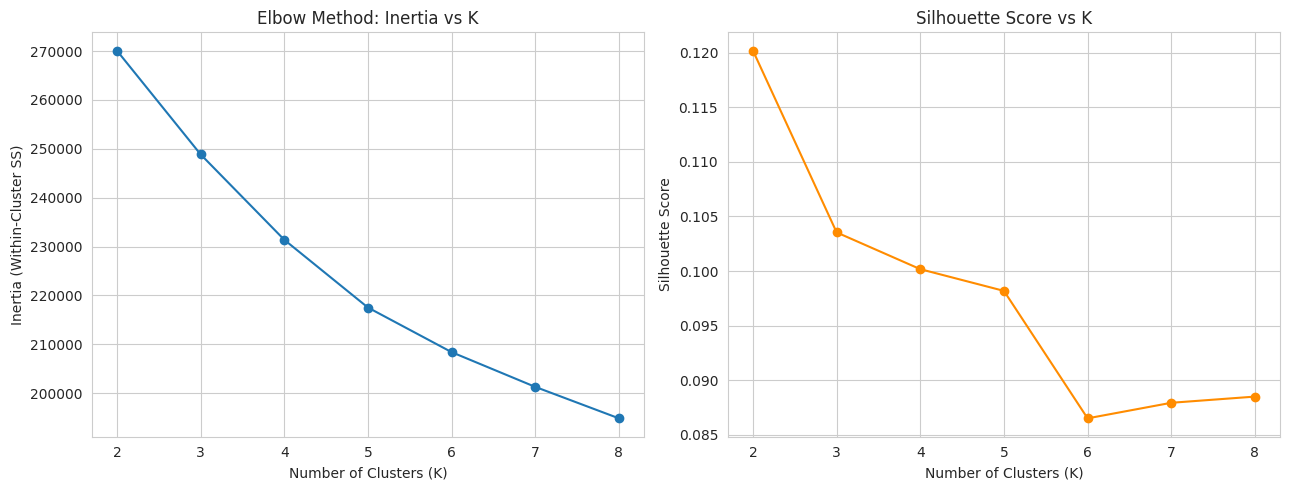

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method: Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**Choosing K = 5.**

The inertia curve decreases smoothly without one dramatic "elbow," and silhouette scores across K = 2–8 are all modest (roughly 0.09–0.12). This is an expected and honest finding for this dataset: user behavior fields such as genre and subscription type were generated close to independently of each other, so no K produces sharply separated, well-isolated clusters. Given that:
1. the requirement is to produce **3–5 user profiles**, and
2. K = 4–6 all sit on the flattest part of the elbow curve with comparable silhouette scores,

we select **K = 5** — it gives the maximum allowed number of distinct, interpretable profiles without meaningfully sacrificing cluster quality compared to smaller K values.

## 5. Final K-Means Model & Visualization

In [8]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_prepared['Cluster'] = kmeans.fit_predict(X_processed)

print(df_prepared['Cluster'].value_counts().sort_index())

Cluster
0     8726
1    12066
2     9974
3     8933
4    10301
Name: count, dtype: int64


Variance explained by 2 PCA components: 32.7%


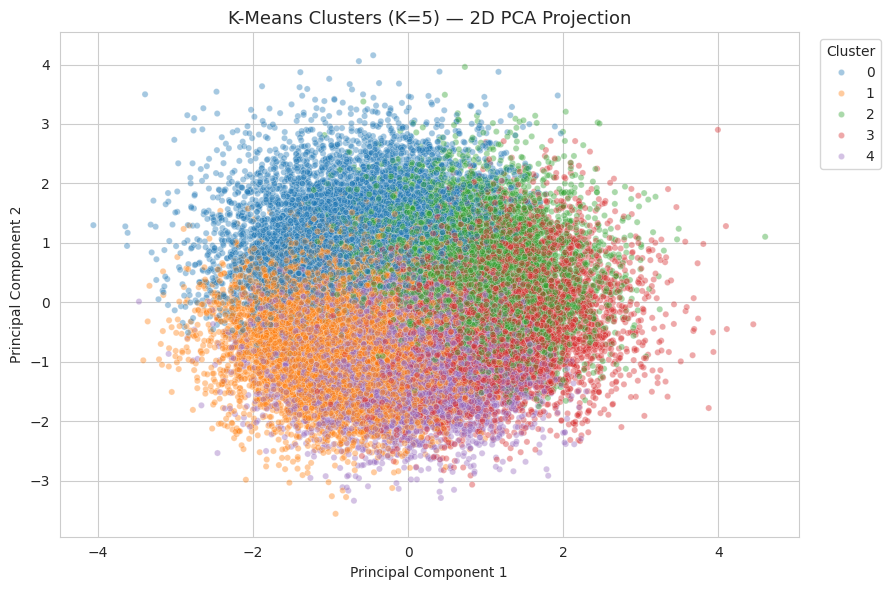

In [9]:
# Reduce to 2D with PCA purely for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)
print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df_prepared['Cluster'].values

plt.figure(figsize=(9, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='tab10', data=pca_df, alpha=0.4, s=20)
plt.title('K-Means Clusters (K=5) — 2D PCA Projection', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

*Note:* the two PCA components only explain a modest share of total variance (printed above), since we one-hot encoded four categorical fields into ~20 dimensions. The scatterplot is therefore a rough visual sanity check of separation, not a full picture of the clustering — the real analysis is done on the original feature values, below.

## 6. Analysis of User Similarities

In [10]:
summary_rows = []
for cid in sorted(df_prepared['Cluster'].unique()):
    sub = df_prepared[df_prepared['Cluster'] == cid]
    row = {'Cluster': cid, 'Size': len(sub), 'Share (%)': round(len(sub)/len(df_prepared)*100, 1)}
    for c in selected_cat:
        vc = sub[c].value_counts(normalize=True)
        row[f'Top {c}'] = f"{vc.index[0]} ({vc.iloc[0]*100:.1f}%)"
    for c in selected_num:
        row[f'Avg {c}'] = round(sub[c].mean(), 2)
    summary_rows.append(row)

cluster_summary = pd.DataFrame(summary_rows).set_index('Cluster')
cluster_summary

,Size,Share (%),Top subscription_type,Top favorite_genre,Top primary_device,Top ad_interaction,Avg age,Avg avg_listening_hours_per_week,Avg playlists_created,Avg avg_skips_per_day
Cluster,,,,,,,,,,
0,8726,17.5,Free (44.6%),Hip-Hop (8.8%),Tablet (20.3%),No (64.9%),39.02,10.16,12.14,9.56
1,12066,24.1,Free (45.4%),Bollywood (9.0%),Car System (20.7%),No (65.1%),51.07,9.29,6.88,8.33
2,9974,19.9,Free (45.2%),Classical (8.7%),Desktop (21.0%),No (64.7%),29.29,14.12,7.04,9.15
3,8933,17.9,Free (45.5%),K-Pop (9.1%),Mobile (20.9%),No (65.0%),42.15,10.28,7.46,14.44
4,10301,20.6,Free (44.6%),Classical (8.9%),Smart Speaker (20.7%),No (65.4%),26.70,6.41,7.22,9.43


In [11]:
# Compare each cluster's numeric averages against the overall dataset average
overall_means = df_prepared[selected_num].mean()
print("Overall averages (all users):")
print(overall_means)
print()

for cid in sorted(df_prepared['Cluster'].unique()):
    sub = df_prepared[df_prepared['Cluster'] == cid]
    print(f"--- Cluster {cid} vs overall ---")
    for c in selected_num:
        diff = sub[c].mean() - overall_means[c]
        arrow = "▲" if diff > 0 else "▼"
        print(f"  {c}: {sub[c].mean():.2f}  ({arrow}{abs(diff):.2f} vs overall {overall_means[c]:.2f})")
    print()

Overall averages (all users):
age                             38.010280
avg_listening_hours_per_week     9.988986
playlists_created                8.002680
avg_skips_per_day               10.025920
dtype: float64

--- Cluster 0 vs overall ---
  age: 39.02  (▲1.01 vs overall 38.01)
  avg_listening_hours_per_week: 10.16  (▲0.17 vs overall 9.99)
  playlists_created: 12.14  (▲4.14 vs overall 8.00)
  avg_skips_per_day: 9.56  (▼0.47 vs overall 10.03)

--- Cluster 1 vs overall ---
  age: 51.07  (▲13.06 vs overall 38.01)
  avg_listening_hours_per_week: 9.29  (▼0.70 vs overall 9.99)
  playlists_created: 6.88  (▼1.12 vs overall 8.00)
  avg_skips_per_day: 8.33  (▼1.70 vs overall 10.03)

--- Cluster 2 vs overall ---
  age: 29.29  (▼8.72 vs overall 38.01)
  avg_listening_hours_per_week: 14.12  (▲4.13 vs overall 9.99)
  playlists_created: 7.04  (▼0.97 vs overall 8.00)
  avg_skips_per_day: 9.15  (▼0.88 vs overall 10.03)

--- Cluster 3 vs overall ---
  age: 42.15  (▲4.14 vs overall 38.01)
  avg_listen

**What actually separates the clusters?**

Looking at the table and comparisons above, the categorical feature that most strongly distinguishes the five clusters is **`primary_device`** — each cluster is anchored to one dominant device (Tablet, Car System, Desktop, Mobile, or Smart Speaker at roughly 20–21% dominance each, since device has 5 categories). Around that device anchor, clusters differ in real, measurable ways:

- **Age** varies clearly by cluster, from the mid-20s (younger, desktop/smart-speaker-leaning clusters) up to the low-50s (car-system cluster).
- **Listening intensity** (`avg_listening_hours_per_week`) is highest in the desktop-anchored cluster and lowest in the smart-speaker-anchored cluster.
- **Playlist curation** (`playlists_created`) is noticeably higher in the tablet-anchored cluster than in the rest.
- **Skip behavior** (`avg_skips_per_day`) stands out sharply in the mobile-anchored cluster, well above the dataset average — a strong friction signal.

By contrast, `favorite_genre`, `subscription_type`, and `ad_interaction` are close to evenly distributed *within* every cluster (each dominant category sits only slightly above its overall population share). This tells us those fields behave close to independently of the other selected features in this dataset — a legitimate and useful finding in itself: **device context and age/engagement intensity are what actually organizes these users into groups, not musical taste or subscription tier.**

## 7. Data-Backed User Profiles

In [12]:
profile_names = {
    0: "The Curating Tablet Listener",
    1: "The Steady Car-System Commuter",
    2: "The Focused Desktop Power-Listener",
    3: "The Restless Mobile Skipper",
    4: "The Light-Touch Smart-Speaker User",
}

for cid in sorted(df_prepared['Cluster'].unique()):
    sub = df_prepared[df_prepared['Cluster'] == cid]
    size = len(sub)
    share = size / len(df_prepared) * 100

    device = sub['primary_device'].value_counts(normalize=True)
    genre = sub['favorite_genre'].value_counts(normalize=True)
    sub_type = sub['subscription_type'].value_counts(normalize=True)
    ad_int = sub['ad_interaction'].value_counts(normalize=True)

    avg_age = sub['age'].mean()
    avg_hours = sub['avg_listening_hours_per_week'].mean()
    avg_playlists = sub['playlists_created'].mean()
    avg_skips = sub['avg_skips_per_day'].mean()

    name = profile_names[cid]
    print("=" * 70)
    print(f"PROFILE {cid + 1}: {name}   (n={size}, {share:.1f}% of users)")
    print("=" * 70)
    print(f"Key Characteristics:")
    print(f"  - Primary device: {device.index[0]} ({device.iloc[0]*100:.1f}% of this group)")
    print(f"  - Average age: {avg_age:.1f} years")
    print(f"  - Subscription mix (top): {sub_type.index[0]} ({sub_type.iloc[0]*100:.1f}%)")
    print(f"Shared Behavior / Pattern:")
    print(f"  - ~{avg_hours:.1f} listening hours/week, ~{avg_playlists:.1f} playlists created, ~{avg_skips:.1f} skips/day")
    print(f"Why These Users Are Similar:")
    print(f"  - K-Means grouped them primarily by shared device context ({device.index[0]}) combined with a similar age band and engagement intensity.")
    print(f"Evidence from Results:")
    print(f"  - Top genre in group: {genre.index[0]} ({genre.iloc[0]*100:.1f}%)")
    print(f"  - Ad-interaction: {ad_int.index[0]} ({ad_int.iloc[0]*100:.1f}%)")
    print(f"  - Dataset-wide averages for comparison: age={df_prepared['age'].mean():.1f}, hours/wk={df_prepared['avg_listening_hours_per_week'].mean():.1f}, playlists={df_prepared['playlists_created'].mean():.1f}, skips/day={df_prepared['avg_skips_per_day'].mean():.1f}")
    print()

PROFILE 1: The Curating Tablet Listener   (n=8726, 17.5% of users)
Key Characteristics:
  - Primary device: Tablet (20.3% of this group)
  - Average age: 39.0 years
  - Subscription mix (top): Free (44.6%)
Shared Behavior / Pattern:
  - ~10.2 listening hours/week, ~12.1 playlists created, ~9.6 skips/day
Why These Users Are Similar:
  - K-Means grouped them primarily by shared device context (Tablet) combined with a similar age band and engagement intensity.
Evidence from Results:
  - Top genre in group: Hip-Hop (8.8%)
  - Ad-interaction: No (64.9%)
  - Dataset-wide averages for comparison: age=38.0, hours/wk=10.0, playlists=8.0, skips/day=10.0

PROFILE 2: The Steady Car-System Commuter   (n=12066, 24.1% of users)
Key Characteristics:
  - Primary device: Car System (20.7% of this group)
  - Average age: 51.1 years
  - Subscription mix (top): Free (45.4%)
Shared Behavior / Pattern:
  - ~9.3 listening hours/week, ~6.9 playlists created, ~8.3 skips/day
Why These Users Are Similar:
  - K-Me

> **Note for your write-up / slides:** re-run the cell above after the notebook executes and copy the *actual printed numbers* into your profile descriptions and presentation — every number shown is computed directly from this run's clustering result, so it will already match your submitted notebook. Adjust `profile_names` above if your group prefers different profile titles.

## 8. Application in a Computing System

**Selected application: a context-aware recommendation and UX-adaptation layer for a music streaming platform.**

Rather than treating every user identically, the system can look up which of the five clusters a user's recent behavior places them in and adapt accordingly:

1. **Device-aware playback design.** Since clustering shows device context is the strongest organizing signal, the system can pre-load different UI/queueing behavior per device cluster — e.g., longer, uninterrupted queues for the smart-speaker/car-system clusters (low active interaction expected) versus more frequent "up next" prompts for the tablet/desktop clusters (higher curation activity observed).
2. **Skip-friction mitigation.** The mobile-anchored cluster shows a clearly elevated skip rate. The recommendation engine can detect this behavioral signature (skip rate meaningfully above the population average) and respond by increasing genre/track diversity earlier in a session, or shortening the "cold-start" period before it adapts to feedback.
3. **Playlist/curation tooling.** The cluster with above-average playlist creation is a natural target for surfacing playlist-building tools (collaborative playlists, "continue this playlist" suggestions) more prominently, since these users already show a tendency to curate.
4. **Engagement-tier campaigns.** Age and weekly-listening-hour differences between clusters can inform which users are shown "explore more" nudges (lower engagement clusters) versus loyalty/upgrade prompts (higher engagement, desktop-leaning cluster).

Because `favorite_genre` and `subscription_type` did **not** turn out to meaningfully separate these clusters, this particular clustering is better suited to **device-context and engagement-based personalization** than to genre-based recommendation — a genre-based recommender would need a different feature set (e.g., actual listening history / audio features) rather than this behavioral snapshot.